# Notebook 6: Inferens via joint sandsynligheder og diskrete SFS-observationer

I denne notebook vil jeg undersøge Bayesiansk inferens baseret på joint sandsynligheder den eksakte sandsynlighedstabel over kombinationer af diskrete mutationshændelser (singletons, doubletons osv.). Dette er anderledes fra TMRCA-inferens: i stedet for kontinuerte absorptionstider bruger jeg tælle-data om, hvilken kategori hver mutation falder i.

Via *joint_prob_graph* konstrueres en udvidet graf, der tracker alle kombinationer af diskrete hændelser (mutationer) op til en øvre grænse. Absorptionstilstandene i denne graf svarer til specifikke observationstyper, og SVGD kan da optimere mod den observerede fordelingen.

Jeg vil gerne undersøge følgende spørgsmål:

- Hvad er informationsindholdet i joint SFS frem for marginal SFS? 
- Hvornår er modellens joint-sandsynlighedstabel en god nok approksimation, og hvad er effekten af *tot_reward_limit*?

In [ ]:
# Importer de nødvendige pakker 
import os
os.environ["CUDA_VISIBLE_DEVICES"] = "0"   
os.environ["XLA_FLAGS"] = "--xla_force_host_platform_device_count=1"

from phasic import (
    Graph, with_ipv,
    GaussPrior, HalfCauchyPrior, DataPrior,
    Adam, ExpStepSize, ExpRegularization, clear_caches,
    StateIndexer, Property,
) 
import numpy as np
import jax.numpy as jnp
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm
import seaborn as sns
from functools import partial
from itertools import combinations_with_replacement
all_pairs = partial(combinations_with_replacement, r=2)
%config InlineBackend.figure_format = 'svg'

np.random.seed(42)
sns.set_palette('tab10')
plt.rcParams['figure.figsize'] = (10, 4)

clear_caches()

# Hjælpefunktion til sampling af joint-observationer
def sample_joint_observations(joint_prob_graph, theta, nr_observations=1000):
    joint_prob_graph.update_weights(theta)
    table = joint_prob_graph.joint_prob_table()
    p = table['prob'] / table['prob'].sum()
    idx = np.random.choice(table.index.values, nr_observations, p=p.to_numpy())
    return table.loc[idx, table.columns[:-1]].to_numpy().tolist()

print("Setup færdig.")

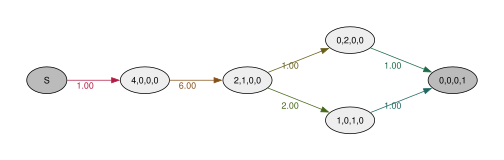

In [2]:
# Standard koalescent med StateIndexer 
nr_samples = 4
indexer = StateIndexer(
    lineage=[Property('descendants', min_value=1, max_value=nr_samples)]
)

@with_ipv([nr_samples]+[0]*(nr_samples-1))
def coalescent_1param(state):
    transitions = []
    for i, j in all_pairs(indexer.lineage):
        p1 = indexer.lineage.index_to_props(i)
        p2 = indexer.lineage.index_to_props(j)
        same = int(i == j)
        if same and state[i] < 2: continue
        if not same and (state[i] < 1 or state[j] < 1): continue
        new = state.copy()
        new[i] -= 1; new[j] -= 1
        k = indexer.lineage.props_to_index(descendants=p1.descendants+p2.descendants)
        new[k] += 1
        transitions.append([new, [state[i]*(state[j]-same)/(1+same)]])
    return transitions

graph = Graph(coalescent_1param)
graph.plot()

## Effekten af *tot_reward_limi* på sandsynlighedsdækning

*tot_reward_limit* sætter en øvre grænse for det samlede antal mutationer, der spores i joint-grafen. Observationer der overskrider grænsen sendes til en 'trash'-tilstand og bidrager ikke til sandsynlighedstabellen. Dette skaber et *deficit* sandsynligheder der mangler i tabellen.

### Hypotese 

- Deficitet falder hurtigt med *tot_reward_limit* for lave mutationsrater og store $\theta$, men langsomt for høje mutationsrater. For *tot_reward_limit $=3$* og mutationsrate $=1$ vil deficitet være under $5\%$, mens det ved mutationsrate $=5$ vil overstige $30\%$. Inferencekvaliteten (SVGD-estimat bias) er direkte korreleret med deficitet.

In [3]:
# Deficit som funktion af tot_reward_limit og mutationsrate
mutation_rates = [0.5, 1.0, 2.0, 5.0]
reward_limits  = [1, 2, 3, 4, 5, 7]
true_theta_rate = [7.0]  # koalescensrate

deficit_rows = []
for mu in mutation_rates:
    for lim in reward_limits:
        jp_graph = graph.joint_prob_graph(indexer, tot_reward_limit=lim, mutation_rate=mu)
        jp_graph.update_weights(true_theta_rate + [mu])
        table = jp_graph.joint_prob_table()
        deficit = float(1 - table['prob'].sum())
        deficit_rows.append({'mu': mu, 'tot_reward_limit': lim, 'Deficit': round(deficit, 5),
                             'n_observationer i tabel': len(table)})

df_deficit = pd.DataFrame(deficit_rows)
print(df_deficit.to_string(index=False))

 mu  tot_reward_limit  Deficit  n_observationer i tabel
0.5                 1  0.01031                        4
0.5                 2  0.00078                       10
0.5                 3  0.00006                       20
0.5                 4  0.00000                       35
0.5                 5  0.00000                       56
0.5                 7  0.00000                      120
1.0                 1  0.10883                        4
1.0                 2  0.02772                       10
1.0                 3  0.00664                       20
1.0                 4  0.00154                       35
1.0                 5  0.00035                       56
1.0                 7  0.00002                      120
2.0                 1  0.53274                        4
2.0                 2  0.33185                       10
2.0                 3  0.19606                       20
2.0                 4  0.11198                       35
2.0                 5  0.06255                  

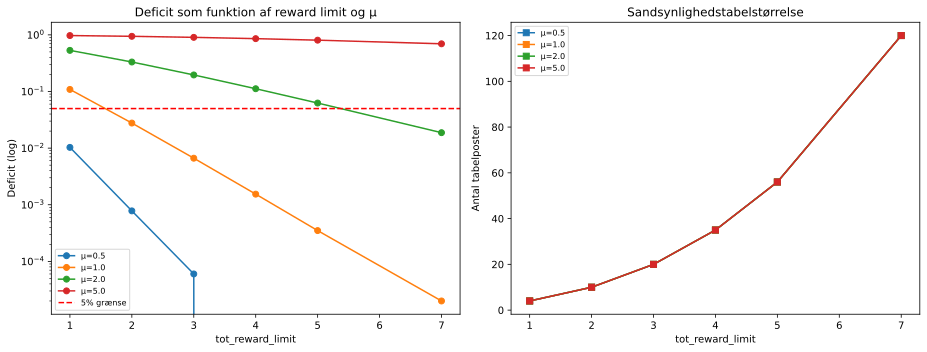

In [4]:
# Visualiser deficit
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

for mu, grp in df_deficit.groupby('mu'):
    axes[0].semilogy(grp['tot_reward_limit'], grp['Deficit'], 'o-', label=f'μ={mu}')
    axes[1].plot(grp['tot_reward_limit'], grp['n_observationer i tabel'], 's-', label=f'μ={mu}')

axes[0].axhline(0.05, color='red', linestyle='--', label='5% grænse')
axes[0].set_xlabel('tot_reward_limit'); axes[0].set_ylabel('Deficit (log)')
axes[0].set_title('Deficit som funktion af reward limit og μ')
axes[0].legend(fontsize=8)

axes[1].set_xlabel('tot_reward_limit'); axes[1].set_ylabel('Antal tabelposter')
axes[1].set_title('Sandsynlighedstabelstørrelse')
axes[1].legend(fontsize=8)
plt.tight_layout(); plt.show()

## Joint SFS vs. marginal SFS: Informationsindhold

Marginal SFS giver mig det forventede antal singletons, doubletons osv. separat. Joint SFS giver mig den samlede sandsynlighed for specifikke kombinationer (fx '1 singleton og 2 doubletons'). Jeg undersøger, om joint-inferens giver smallere posterior end marginal-inferens.

### Hypotese 

- Joint SFS-inferens (via *joint_prob_graph*) giver en smallere og bedre kalibreret posterior for $\theta$ end marginal inferens fra TMRCA-observationer, fordi joint-observationer indeholder information om kovariansen mellem SFS-komponenter. Gevinsten er størst for lav $\theta$ (færre mutationer $\rightarrow$ joint-information er mere diskriminerende).

In [ ]:
mu = 1.0
N_OBS = 1000
step = ExpStepSize(first_step=0.05, last_step=0.005, tau=40.0)

jp_graph = graph.joint_prob_graph(indexer, tot_reward_limit=3, mutation_rate=mu)

results_compare = []
theta_values = [2.0, 5.0, 10.0, 20.0]  # Varierende sand θ

for true_theta in theta_values:
    # 1. Joint-observationer
    obs_joint = sample_joint_observations(jp_graph, [true_theta, mu], N_OBS)
    
    # 2. TMRCA-observationer
    graph.update_weights([true_theta])
    obs_tmrca = graph.sample(N_OBS)
    
    # Prior via DataPrior
    prior_jp   = DataPrior(jp_graph, obs_joint)
    prior_tmrca = GaussPrior(ci=[true_theta*0.3, true_theta*3])
    
    # SVGD: joint
    sv_joint = jp_graph.svgd(
        obs_joint,
        fixed=[(1, mu)],
        prior=prior_jp,
        learning_rate=step,
        n_iterations=300
    )
    res_j = sv_joint.get_results()
    
    # SVGD: TMRCA
    sv_tmrca = graph.svgd(
        obs_tmrca,
        prior=prior_tmrca,
        learning_rate=step,
        n_iterations=300
    )
    res_t = sv_tmrca.get_results()
    
    results_compare.append({
        'Sand θ': true_theta,
        'Joint mean': round(res_j['theta_mean'][0].item(), 3),
        'Joint std':  round(res_j['theta_std'][0].item(), 4),
        'TMRCA mean': round(res_t['theta_mean'].item(), 3),
        'TMRCA std':  round(res_t['theta_std'].item(), 4),
    })
    print(f"θ={true_theta}: Joint std={res_j['theta_std'][0].item():.4f}  TMRCA std={res_t['theta_std'].item():.4f}")

df_compare = pd.DataFrame(results_compare)
print("\n", df_compare.to_string(index=False))

In [ ]:
# Visualiser sammenligning
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

axes[0].plot(df_compare['Sand θ'], df_compare['Joint mean'], 'o-', label='Joint SFS')
axes[0].plot(df_compare['Sand θ'], df_compare['TMRCA mean'], 's-', label='TMRCA')
axes[0].plot(df_compare['Sand θ'], df_compare['Sand θ'], 'k--', label='Sand θ')
axes[0].set_xlabel('Sand θ'); axes[0].set_ylabel('Posterior mean'); axes[0].legend()
axes[0].set_title('Posterior mean: Joint vs. TMRCA')

axes[1].plot(df_compare['Sand θ'], df_compare['Joint std'], 'o-', label='Joint SFS')
axes[1].plot(df_compare['Sand θ'], df_compare['TMRCA std'], 's-', label='TMRCA')
axes[1].set_xlabel('Sand θ'); axes[1].set_ylabel('Posterior std')
axes[1].set_title('Posterior usikkerhed: Joint vs. TMRCA')
axes[1].legend()
plt.suptitle('Informationsindhold: Joint SFS vs. TMRCA-observationer', fontsize=12)
plt.tight_layout(); plt.show()

## Joint sandsynlighedstabellens struktur og det 2D-mønster

Jeg undersøger, hvordan joint-sandsynlighedstabellen afhænger af $\theta$. Specielt: Ændrer den relative sandsynlighed for (singleton, doubleton)-kombinationer sig med $\theta$ på en måde, der giver stærkt diskriminerende signal?

### Hypotese 

- Heatmapmet over joint-(1-ton, 2-ton)-sandsynligheder ændrer formen systematisk med $\theta$: lav $\theta$ giver koncentration langs diagonalen (få mutationer, men de er korrelerede), mens høj $\theta$ giver en mere symmetrisk, rektangulær fordeling. Denne form-ændring indeholder mere information om $\theta$ end summen af marginalerne.

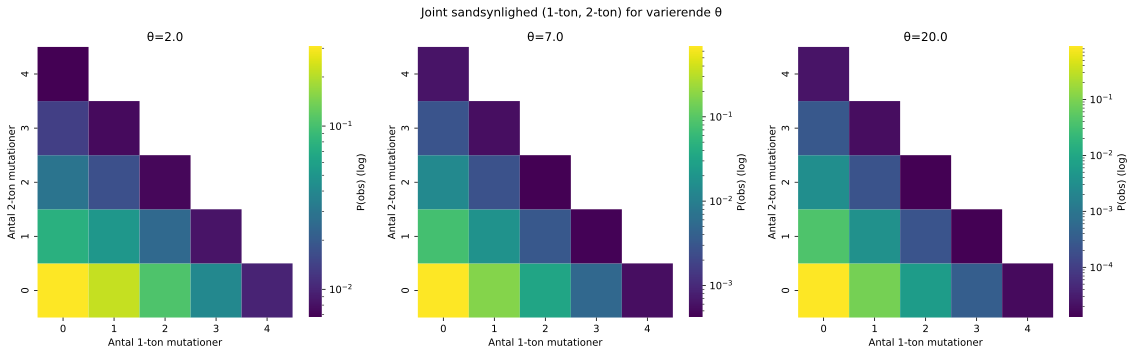

In [6]:
mu_heatmap = 1.0
jp_graph_hm = graph.joint_prob_graph(indexer, tot_reward_limit=4, mutation_rate=mu_heatmap)

theta_heatmap = [2.0, 7.0, 20.0]
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

for ax, theta in zip(axes, theta_heatmap):
    jp_graph_hm.update_weights([theta, mu_heatmap])
    table = jp_graph_hm.joint_prob_table()
    
    # 2D pivot: 1-ton vs 2-ton
    ton_cols = ['descendants_1', 'descendants_2']
    if all(c in table.columns for c in ton_cols):
        plot_df = table[ton_cols + ['prob']].groupby(ton_cols).sum().reset_index()
        pivot = plot_df.pivot(index='descendants_2', columns='descendants_1', values='prob').fillna(0)
        sns.heatmap(pivot, ax=ax, cmap='viridis', norm=LogNorm(),
                    cbar_kws={'label': 'P(obs) (log)'})
        ax.set_title(f'θ={theta}')
        ax.set_xlabel('Antal 1-ton mutationer')
        ax.set_ylabel('Antal 2-ton mutationer')
        ax.invert_yaxis()

plt.suptitle('Joint sandsynlighed (1-ton, 2-ton) for varierende θ', fontsize=12)
plt.tight_layout(); plt.show()

## Prøvestørrelse effekt på joint-inferens

### Hypotese 

- Joint SFS-inferens konvergerer til sand $\theta$ med $O(1/\sqrt{n})$ præcision ligesom TMRCA-inferens, men posterior-bredden er smallere for joint-inferens allerede ved $n=100$ observationer. Gevinsten er proportional med joint-tabelstørrelsen store tabeller (høj *tot_reward_limit*) giver mere information per observation.

In [ ]:
true_theta_ss = 7.0
mu_ss = 1.0
jp_ss = graph.joint_prob_graph(indexer, tot_reward_limit=3, mutation_rate=mu_ss)
graph.update_weights([true_theta_ss])

sample_sizes_joint = [50, 100, 250, 500, 1000, 3000]
step_ss = ExpStepSize(first_step=0.05, last_step=0.005, tau=30.0)
rows_ss = []

for n in sample_sizes_joint:
    # Joint-observationer
    obs_j = sample_joint_observations(jp_ss, [true_theta_ss, mu_ss], n)
    obs_t = graph.sample(n)
    
    prior_j = DataPrior(jp_ss, obs_j)
    prior_t = GaussPrior(ci=[2, 20])
    
    sv_j = jp_ss.svgd(obs_j, fixed=[(1, mu_ss)], prior=prior_j,
                       learning_rate=step_ss, n_iterations=250)
    sv_t = graph.svgd(obs_t, prior=prior_t,
                       learning_rate=step_ss, n_iterations=250)
    
    rj = sv_j.get_results(); rt = sv_t.get_results()
    rows_ss.append({
        'n': n,
        'Joint mean': round(rj['theta_mean'][0].item(), 3),
        'Joint std':  round(rj['theta_std'][0].item(), 4),
        'TMRCA mean': round(rt['theta_mean'].item(), 3),
        'TMRCA std':  round(rt['theta_std'].item(), 4),
    })
    print(f"n={n:5d}: Joint std={rj['theta_std'][0].item():.4f}  TMRCA std={rt['theta_std'].item():.4f}")

df_ss = pd.DataFrame(rows_ss)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
axes[0].loglog(df_ss['n'], df_ss['Joint std'], 'o-', label='Joint SFS')
axes[0].loglog(df_ss['n'], df_ss['TMRCA std'], 's-', label='TMRCA')
# Theoretical O(1/sqrt(n)) line
n_arr = np.array(df_ss['n'], dtype=float)
axes[0].loglog(n_arr, df_ss['Joint std'].iloc[0] * np.sqrt(df_ss['n'].iloc[0]/n_arr),
               'k--', alpha=0.5, label='O(1/√n) reference')
axes[0].set_xlabel('Prøvestørrelse n (log)'); axes[0].set_ylabel('Posterior std (log)')
axes[0].set_title('Konvergenshastighed: Joint vs. TMRCA')
axes[0].legend()

axes[1].semilogx(df_ss['n'], df_ss['Joint mean'], 'o-', label='Joint')
axes[1].semilogx(df_ss['n'], df_ss['TMRCA mean'], 's-', label='TMRCA')
axes[1].axhline(true_theta_ss, color='red', linestyle='--', label=f'Sand θ={true_theta_ss}')
axes[1].set_xlabel('Prøvestørrelse n'); axes[1].set_ylabel('Posterior mean')
axes[1].set_title('Bias som funktion af n')
axes[1].legend()

plt.suptitle(f'Prøvestørrelse effekt (sand θ={true_theta_ss}, μ={mu_ss})', fontsize=12)
plt.tight_layout(); plt.show()

## To-locus ARG: Joint inferens af koalescens og rekombination

Den naturlige udvidelse er at bruge joint-sandsynligheder fra et two-locus ARG til at inferere både koalescensrate og rekombinationsrate. Jeg undersøger, om joint-observationer kan adskille de to parametre.

### Hypotese 

- To-locus joint-observationer (hvilken kombination af allel-typer ses ved de to loci) indeholder information om rekombinationsraten. Jeg forventer en klart identificerbar posterior for ($\theta_0$, $R$), fordi høj rekombination øger sandsynligheden for uafhængige SFS ved de to loci.

ARG tilstandsrum: 32 tilstande


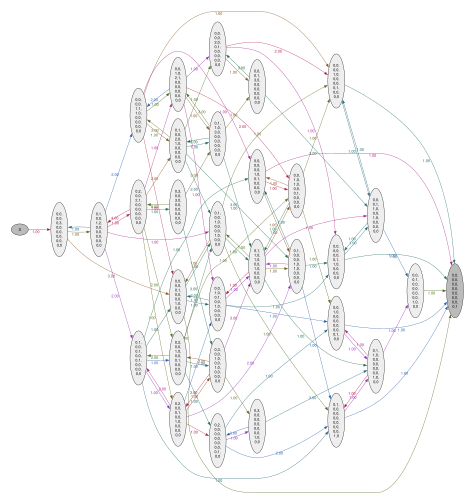

In [3]:
# Two-locus ARG model 
nr_samples_arg = 3
indexer_arg = StateIndexer(
    descendants=[
        Property('loc1', min_value=0, max_value=nr_samples_arg),
        Property('loc2', min_value=0, max_value=nr_samples_arg)
    ]
)

initial_arg = [0] * indexer_arg.state_length
initial_arg[indexer_arg.descendants.props_to_index(loc1=1, loc2=1)] = nr_samples_arg

@with_ipv(initial_arg)
def two_locus_arg(state, indexer=None):
    transitions = []
    if state.sum() <= 1: return transitions
    for i in range(indexer.state_length):
        if state[i] == 0: continue
        pi = indexer.descendants.index_to_props(i)
        for j in range(i, indexer.state_length):
            if state[j] == 0: continue
            pj = indexer.descendants.index_to_props(j)
            same = int(i == j)
            if same and state[i] < 2: continue
            if not same and (state[i] < 1 or state[j] < 1): continue
            child = state.copy(); child[i] -= 1; child[j] -= 1
            loc1 = pi.loc1 + pj.loc1; loc2 = pi.loc2 + pj.loc2
            if loc1 <= nr_samples_arg and loc2 <= nr_samples_arg:
                child[indexer.props_to_index(loc1=loc1, loc2=loc2)] += 1
                transitions.append([child, [state[i]*(state[j]-same)/(1+same), 0]])
        # Rekombination
        if pi.loc1 > 0 and pi.loc2 > 0:
            child = state.copy(); child[i] -= 1
            child[indexer.props_to_index(loc1=pi.loc1, loc2=0)] += 1
            child[indexer.props_to_index(loc1=0, loc2=pi.loc2)] += 1
            transitions.append([child, [0, 1]])
    return transitions

graph_arg = Graph(two_locus_arg, indexer=indexer_arg)
print(f"ARG tilstandsrum: {graph_arg.vertices_length()} tilstande")
graph_arg.plot(max_nodes=50, nodesep=0.3)

In [4]:
# Byg joint probability graph for ARG
mu_arg = 1.0
jp_arg = graph_arg.joint_prob_graph(
    indexer_arg,
    reward_only=['loc1', 'loc2'],
    reward_limit=1,
    tot_reward_limit=2,
    mutation_rate=mu_arg
)
print(f"Joint ARG graph: {jp_arg.vertices_length()} tilstande")

true_theta_arg = [10.0, 1.0, mu_arg]  # [koalescens, rekombination, mutation]
obs_arg = sample_joint_observations(jp_arg, true_theta_arg, nr_observations=1000)
print(f"Samplet {len(obs_arg)} observationer. Første 5: {obs_arg[:5]}")

Joint ARG graph: 666 tilstande
Samplet 1000 observationer. Første 5: [[0, 0, 0, 0, 0, 0, 0, 0], [0, 1, 0, 0, 0, 0, 1, 0], [0, 0, 1, 0, 0, 0, 0, 0], [0, 0, 0, 0, 0, 0, 0, 0], [0, 0, 0, 0, 0, 0, 0, 0]]


In [ ]:
# SVGD inferens for ARG: estimer koalescens og rekombination
step_arg = ExpStepSize(first_step=0.1, last_step=0.01, tau=50.0)

sv_arg = jp_arg.svgd(
    observed_data=obs_arg,
    fixed=[(2, mu_arg)],  # Fix mutationsrate
    prior=[
        GaussPrior(ci=[5, 25]),   # θ₀ (koalescens)
        GaussPrior(ci=[0, 5]),    # θ₁ (rekombination)
        None                       # μ (fixed)
    ],
    n_particles=60,
    n_iterations=300,
    optimizer=Adam(learning_rate=0.25),
)
sv_arg.summary()

res_arg = sv_arg.get_results()
print(f"\nSand θ: koalescens={true_theta_arg[0]}, rekombination={true_theta_arg[1]}")
print(f"Estimat: θ₀={res_arg['theta_mean'][0]:.3f}, θ₁={res_arg['theta_mean'][1]:.3f}")

In [5]:
# SVGD inferens for ARG: estimer koalescens og rekombination
step_arg = ExpStepSize(first_step=0.1, last_step=0.01, tau=50.0)

sv_arg = jp_arg.svgd(
    observed_data=obs_arg,
    fixed=[(2, mu_arg)],  # Fix mutationsrate
    prior=[
        GaussPrior(ci=[5, 25]),   # θ₀ (koalescens)
        GaussPrior(ci=[0, 5]),    # θ₁ (rekombination)
        None                       # μ (fixed)
    ],
    n_particles=60,
    n_iterations=300,
    learning_rate=step_arg,
)
sv_arg.summary()

res_arg = sv_arg.get_results()
print(f"\nSand θ: koalescens={true_theta_arg[0]}, rekombination={true_theta_arg[1]}")
print(f"Estimat: θ₀={res_arg['theta_mean'][0]:.3f}, θ₁={res_arg['theta_mean'][1]:.3f}")

: 

In [ ]:
# Pairwise posterior for ARG
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
sv_arg.plot_pairwise(true_theta=[true_theta_arg[0], true_theta_arg[1]], ax=axes[0])
axes[0].set_title('Joint posterior (θ₀=koalescens, θ₁=rekombination)')
sv_arg.plot_convergence(ax=axes[1])
axes[1].set_title('SVGD konvergens')
plt.suptitle('Two-locus ARG: joint inferens af koalescens og rekombination', fontsize=12)
plt.tight_layout(); plt.show()

## Multi-feature SVGD: Singleton, doubleton og tripleton separat

Frem for blot TMRCA kan jeg bruge de tre SFS-komponenter (singleton, doubleton, tripleton grenlængder) som separate features i SVGD. Dette giver mere information per observation, da kovariansen mellem features udnyttes.

### Spørgsmål 

- Giver multi-feature SVGD (alle tre SFS-komponenter) en smallere posterior end single-feature (kun TMRCA eller samlede grenlængde)? Og er gevinsten størst for lav eller høj θ?

In [ ]:
nr_samples = 4

@with_ipv([nr_samples] + [0]*(nr_samples-1))
def coalescent_1param(state):
    transitions = []
    for i in range(state.size):
        for j in range(i, state.size):
            same = int(i == j)
            if same and state[i] < 2: continue
            if not same and (state[i] < 1 or state[j] < 1): continue
            new = state.copy()
            new[i] -= 1; new[j] -= 1; new[i+j+1] += 1
            transitions.append([new, [state[i]*(state[j]-same)/(1+same)]])
    return transitions

true_theta = [7.0]
graph = Graph(coalescent_1param)
graph.update_weights(true_theta)

rewards = graph.states().T[:-1]  # 1-ton, 2-ton, 3-ton (ingen 4-ton)
N_OBS = 3000
prior = GaussPrior(ci=[3, 15])
step = ExpStepSize(first_step=0.05, last_step=0.005, tau=30.0)

# Build sparse multi-feature data
obs_matrix = np.full((N_OBS * rewards.shape[0], rewards.shape[0]), np.nan)
for i in range(rewards.shape[0]):
    obs_matrix[i*N_OBS:(i+1)*N_OBS, i] = graph.sample(N_OBS, rewards=rewards[i])

sparse_obs = dense_to_sparse(obs_matrix)

# Sammenlign tre observationstyper
results = {}

# 1. TMRCA
data_tmrca = graph.sample(N_OBS)
sv1 = graph.svgd(data_tmrca, prior=prior, learning_rate=step, n_iterations=300)
results['TMRCA'] = sv1.get_results()

# 2. Total branch length
total_reward = rewards.sum(axis=0)
data_total = graph.sample(N_OBS, rewards=total_reward)
sv2 = graph.svgd(data_total, rewards=total_reward, prior=prior,
                  learning_rate=step, n_iterations=300)
results['Total branch length'] = sv2.get_results()

# 3. Multi-feature: 1-ton + 2-ton + 3-ton
sv3 = graph.svgd(sparse_obs, rewards=rewards, prior=prior,
                  learning_rate=step, n_iterations=300)
results['Multi-feature SFS'] = sv3.get_results()

# Rapporter
print(f"Sand θ = {true_theta[0]}")
print(f"{'Metode':<25} {'θ_mean':>10} {'θ_std':>10} {'CI_low':>8} {'CI_high':>8}")
print("-" * 65)
for name, res in results.items():
    print(f"{name:<25} {res['theta_mean'].item():>10.4f} {res['theta_std'].item():>10.5f} "
          f"{res['ci_low'].item():>8.3f} {res['ci_high'].item():>8.3f}")

In [ ]:
# Visualiser de tre posteriors side om side
fig, axes = plt.subplots(1, 3, figsize=(13, 4))
svgd_list = [sv1, sv2, sv3]
names = ['TMRCA', 'Total branch length', 'Multi-feature SFS']
for ax, sv, name, res in zip(axes, svgd_list, names, results.values()):
    sv.plot_ci(true_theta=true_theta, ax=ax)
    ax.set_title(f'{name}\nstd={res["theta_std"].item():.5f}')
plt.suptitle('Posterior-bredde: TMRCA vs. single-feature vs. multi-feature', fontsize=12)
plt.tight_layout(); plt.show()

# Gevinst som funktion af θ
theta_vals = [2, 5, 10, 20]
N_OBS_SCAN = 2000
rows_gain = []
for theta in theta_vals:
    graph.update_weights([theta])
    d_tmrca = graph.sample(N_OBS_SCAN)
    obs_mf = np.full((N_OBS_SCAN * rewards.shape[0], rewards.shape[0]), np.nan)
    for i in range(rewards.shape[0]):
        obs_mf[i*N_OBS_SCAN:(i+1)*N_OBS_SCAN, i] = graph.sample(N_OBS_SCAN, rewards=rewards[i])
    sparse_mf = dense_to_sparse(obs_mf)
    p_local = GaussPrior(ci=[theta*0.2, theta*3])
    sv_t = graph.svgd(d_tmrca, prior=p_local, learning_rate=step, n_iterations=200)
    sv_m = graph.svgd(sparse_mf, rewards=rewards, prior=p_local,
                       learning_rate=step, n_iterations=200)
    std_t = sv_t.get_results()['theta_std'].item()
    std_m = sv_m.get_results()['theta_std'].item()
    rows_gain.append({'θ': theta, 'std TMRCA': round(std_t,5),
                      'std Multi': round(std_m,5),
                      'Gevinst (%)': round((std_t-std_m)/std_t*100, 1)})

df_gain = pd.DataFrame(rows_gain)
print("\nGevinst ved multi-feature vs. TMRCA:")
print(df_gain.to_string(index=False))
graph.update_weights(true_theta)

## Udforskning af data: Hvad sker der ved forskellige prøvestørrelser og mutationsrater?

Jeg "leger med dataen" ved systematisk at variere prøvestørrelsen $n_{\text{obs}}$ og mutationsrate $\mu$ og observere, hvordan joint probability-tabellen og posterior-estimaterne ændrer sig.

### Spørgsmål 

- Er der en kritisk prøvestørrelse, under hvilken joint-inferens ikke er bedre end TMRCA-inferens? Og hvad er effekten af at bruge den forkerte mutationsrate i inferensen?

In [ ]:
nr_samples_jp = 4

indexer_jp = StateIndexer(
    lineage=[Property('descendants', min_value=1, max_value=nr_samples_jp)]
)

@with_ipv([nr_samples_jp]+[0]*(nr_samples_jp-1))
def coal_joint(state):
    transitions = []
    for i, j in all_pairs_jp(indexer_jp.lineage):
        p1 = indexer_jp.lineage.index_to_props(i)
        p2 = indexer_jp.lineage.index_to_props(j)
        same = int(i == j)
        if same and state[i] < 2: continue
        if not same and (state[i] < 1 or state[j] < 1): continue
        new = state.copy()
        new[i] -= 1; new[j] -= 1
        des = indexer_jp.lineage.props_to_index(descendants=p1.descendants+p2.descendants)
        if des < indexer_jp.lineage.state_length:
            new[des] += 1
        transitions.append([new, [state[i]*(state[j]-same)/(1+same)]])
    return transitions

graph_jp = Graph(coal_joint)
true_theta_jp = [7.0]
mu_true = 1.0

jp_graph = graph_jp.joint_prob_graph(indexer_jp, tot_reward_limit=3, mutation_rate=mu_true)

def sample_joint(jp_g, theta, mu, n):
    jp_g.update_weights(theta + [mu])
    table = jp_g.joint_prob_table()
    p = (table['prob'] / table['prob'].sum()).to_numpy()
    idx = np.random.choice(table.index.values, n, p=p)
    return table.loc[idx, table.columns[:-1]].to_numpy().tolist()

step_jp = ExpStepSize(first_step=0.05, last_step=0.005, tau=30.0)
prior_jp = GaussPrior(ci=[3, 15])

# Del A: Sample size effekt
sample_sizes_jp = [50, 100, 300, 1000, 3000]
rows_ss = []
for n in sample_sizes_jp:
    obs = sample_joint(jp_graph, true_theta_jp, mu_true, n)
    sv = jp_graph.svgd(obs, fixed=[(1, mu_true)], prior=prior_jp,
                        learning_rate=step_jp, n_iterations=250)
    res = sv.get_results()
    rows_ss.append({'n': n,
                    'θ_mean': round(res['theta_mean'][0].item(), 4),
                    'θ_std':  round(res['theta_std'][0].item(), 5),
                    'Indeholder sand': bool(res['ci_low'][0].item() <= true_theta_jp[0] <= res['ci_high'][0].item())})

df_ss = pd.DataFrame(rows_ss)
print("Sample size effekt på joint-inferens:")
print(df_ss.to_string(index=False))

# Del B: Forkert mutationsrate
rows_mu = []
mu_test_values = [0.3, 0.7, 1.0, 1.5, 2.5]
obs_fixed = sample_joint(jp_graph, true_theta_jp, mu_true, 2000)
for mu_fit in mu_test_values:
    # Brug forkert mu til at fitte
    jp_wrong = graph_jp.joint_prob_graph(indexer_jp, tot_reward_limit=3, mutation_rate=mu_fit)
    try:
        sv_w = jp_wrong.svgd(obs_fixed, fixed=[(1, mu_fit)], prior=prior_jp,
                              learning_rate=step_jp, n_iterations=200)
        res_w = sv_w.get_results()
        rows_mu.append({'μ_sand': mu_true, 'μ_fittet': mu_fit,
                        'θ_mean': round(res_w['theta_mean'][0].item(), 4),
                        'θ_std':  round(res_w['theta_std'][0].item(), 5)})
    except Exception as e:
        rows_mu.append({'μ_sand': mu_true, 'μ_fittet': mu_fit, 'θ_mean': None, 'θ_std': None})

df_mu = pd.DataFrame(rows_mu)
print("\nEffekt af forkert mutationsrate (sand μ=1.0):")
print(df_mu.to_string(index=False))
print(f"Sand θ = {true_theta_jp[0]}")